# Notebook 3 — Physics-Guided Unrolled MRI Reconstruction

Learn an unrolled ISTA network with CNN-based proximal operators
and compare fairly against classical ISTA/FISTA with wavelets.

**Architecture**: Each of K unrolled layers performs:
1. **Data consistency** (gradient step): `z = x - η_k · A^H(Ax - y)`
2. **Learned proximal**: `x_{k+1} = ProxCNN_k(z)` (residual CNN block)

**Design choices**:
- Masks correctly place center band at DC in unshifted FFT convention
- Classical baselines use `db4` wavelet (level 4) — same quality as NB2
- SSIM reported alongside PSNR
- Training on phantom augmentations (acknowledged as narrow distribution)

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pywt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim_sk

# device selection
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Device: {device}")


torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "font.size": 11,
    "axes.titlesize": 13, "figure.facecolor": "white",
})

Device: mps


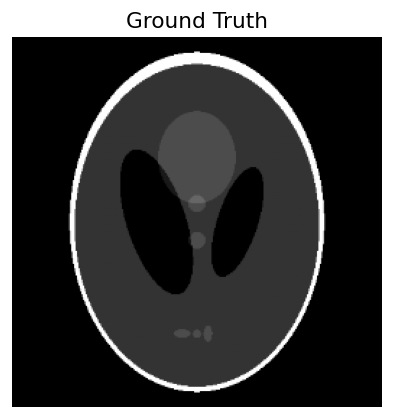

Shape: (256, 256), range: [0.000, 1.000]


In [44]:
image_np = shepp_logan_phantom()
image_np = resize(image_np, (256, 256), anti_aliasing=True).astype(np.float32)
N = image_np.shape[0]

plt.figure(figsize=(4, 4))
plt.imshow(image_np, cmap="gray")
plt.title("Ground Truth"); plt.axis("off")
plt.show()
print(f"Shape: {image_np.shape}, range: [{image_np.min():.3f}, {image_np.max():.3f}]")

## Mask Generation & Forward Model

In [45]:
def random_cartesian_mask(N, accel=4, center_frac=0.08, rng=None):
    """Random Cartesian mask in unshifted FFT convention."""
    if rng is None:
        rng = np.random.default_rng()
    mask = np.zeros((N, N), dtype=np.float32)
    c = max(1, int((center_frac * N) / 2))
    center_cols = np.concatenate([np.arange(0, c), np.arange(N - c, N)])
    num_cols = max(len(center_cols), N // accel)
    remaining = num_cols - len(center_cols)
    candidates = np.setdiff1d(np.arange(N), center_cols)
    if remaining > 0:
        pick = rng.choice(candidates, size=remaining, replace=False)
        cols = np.concatenate([center_cols, pick])
    else:
        cols = center_cols
    mask[:, cols] = 1.0
    return mask

def effective_acceleration(mask):
    return mask.shape[1] / np.sum(mask[0, :])

# PyTorch forward/adjoint
def A_torch(x, mask):
    return torch.fft.fft2(x.squeeze(1), norm="ortho") * mask

def AT_torch(y, mask):
    return torch.fft.ifft2(y * mask, norm="ortho").real.unsqueeze(1)

# NumPy forward/adjoint (for baselines)
def A_np(x, mask):
    return mask * np.fft.fft2(x, norm="ortho")

def AT_np(y, mask):
    return np.fft.ifft2(y * mask, norm="ortho")

In [46]:
def compute_psnr_np(recon, truth):
    data_range = float(truth.max() - truth.min())
    mse = np.mean((recon - truth) ** 2)
    if mse < 1e-15: return float("inf")
    return 20.0 * np.log10(data_range / np.sqrt(mse))

def compute_ssim_np(recon, truth):
    data_range = float(truth.max() - truth.min())
    return ssim_sk(recon, truth, data_range=data_range)

def batch_psnr_torch(x_hat, x_gt):
    dr = x_gt.amax(dim=(-2,-1), keepdim=True) - x_gt.amin(dim=(-2,-1), keepdim=True)
    mse = torch.mean((x_hat - x_gt)**2, dim=(-3,-2,-1))
    psnr = 20.0 * torch.log10(dr.squeeze() / (torch.sqrt(mse) + 1e-12))
    return psnr.mean()

## Classical Baselines: ISTA/FISTA with db4 Wavelets

In [47]:
def wavelet_soft_thresh(x, threshold, wavelet="db4", level=4, mode="periodization"):
    coeffs = pywt.wavedec2(x, wavelet=wavelet, level=level, mode=mode)
    new_coeffs = [coeffs[0]]
    for (cH, cV, cD) in coeffs[1:]:
        new_coeffs.append((
            pywt.threshold(cH, threshold, mode="soft"),
            pywt.threshold(cV, threshold, mode="soft"),
            pywt.threshold(cD, threshold, mode="soft"),
        ))
    rec = pywt.waverec2(new_coeffs, wavelet=wavelet, mode=mode)
    return rec[:x.shape[0], :x.shape[1]]

def ista_np(y, mask, K=10, step=0.3, lam=0.005):
    x = np.real(AT_np(y, mask)).astype(np.float32)
    for _ in range(K):
        grad = 2.0 * np.real(AT_np(A_np(x, mask) - y, mask))
        x = wavelet_soft_thresh(x - step * grad, lam * step).astype(np.float32)
    return x

def fista_np(y, mask, K=10, step=0.3, lam=0.005):
    x = np.real(AT_np(y, mask)).astype(np.float32)
    z = x.copy(); t = 1.0
    for _ in range(K):
        grad = 2.0 * np.real(AT_np(A_np(z, mask) - y, mask))
        x_new = wavelet_soft_thresh(z - step * grad, lam * step).astype(np.float32)
        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
        z = x_new + ((t - 1.0) / t_new) * (x_new - x)
        x, t = x_new, t_new
    return x

## Unrolled ISTA Network

In [48]:
class ProxCNN(nn.Module):
    def __init__(self, channels=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, channels, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(channels, 1, 3, padding=1),
        )
    def forward(self, x):
        return x + self.net(x)


class UnrolledISTA(nn.Module):
    def __init__(self, K=10, init_step=0.2, channels=16, share_prox=False):
        super().__init__()
        self.K = K
        self.share_prox = share_prox
        self.log_step = nn.Parameter(torch.full((K,), np.log(init_step)))
        if share_prox:
            self.prox = ProxCNN(channels=channels)
        else:
            self.prox_layers = nn.ModuleList([ProxCNN(channels=channels) for _ in range(K)])

    def forward(self, y, mask):
        x = AT_torch(y, mask)
        for k in range(self.K):
            step = torch.exp(self.log_step[k])
            grad = AT_torch(A_torch(x, mask) - y, mask)
            z = x - step * grad
            x = self.prox(z) if self.share_prox else self.prox_layers[k](z)
        return x

## Dataset & Training

In [49]:
class PhantomAugDataset(Dataset):
    def __init__(self, base_image_np, num_samples=2000, accel_choices=(2, 4),
                 center_frac=0.08, seed=0):
        self.base = torch.from_numpy(base_image_np)[None, None, :, :]
        self.num_samples = num_samples
        self.accel_choices = accel_choices
        self.center_frac = center_frac
        self.H, self.W = base_image_np.shape
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x = self.base.clone()
        angle = (self.rng.random() * 2 - 1) * 20.0
        scale = 0.9 + 0.2 * self.rng.random()
        tx = (self.rng.random() * 2 - 1) * 0.05
        ty = (self.rng.random() * 2 - 1) * 0.05
        rad = np.deg2rad(angle)
        theta = torch.tensor([
            [scale * np.cos(rad), -scale * np.sin(rad), tx],
            [scale * np.sin(rad),  scale * np.cos(rad), ty],
        ], dtype=torch.float32).unsqueeze(0)
        grid = F.affine_grid(theta, x.size(), align_corners=False)
        x_aug = F.grid_sample(x, grid, align_corners=False, mode="bilinear",
                              padding_mode="zeros").clamp(0, 1)
        R = int(self.rng.choice(self.accel_choices))
        mask_np = random_cartesian_mask(self.H, accel=R, center_frac=self.center_frac, rng=self.rng)
        mask = torch.from_numpy(mask_np).to(torch.complex64).unsqueeze(0)
        return x_aug.squeeze(0), mask.squeeze(0)

center_frac = 0.08
train_ds = PhantomAugDataset(image_np, num_samples=4000, accel_choices=(2, 4),
                              center_frac=center_frac, seed=0)
val_ds   = PhantomAugDataset(image_np, num_samples=400, accel_choices=(2, 4),
                              center_frac=center_frac, seed=999)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Train: 4000, Val: 400


In [50]:
model = UnrolledISTA(K=10, init_step=0.2, channels=16, share_prox=False).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.3)

train_losses, val_psnrs = [], []

for epoch in range(20):
    model.train()
    epoch_loss = 0.0
    for x_gt, mask in train_loader:
        x_gt, mask = x_gt.to(device), mask.to(device).to(torch.complex64)
        y = A_torch(x_gt, mask)
        x_hat = model(y, mask)
        loss = torch.sum((x_hat - x_gt)**2) / (torch.sum(x_gt**2) + 1e-12)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += float(loss.detach().cpu())
    scheduler.step()
    train_losses.append(epoch_loss / len(train_loader))

    model.eval()
    val_ps = []
    with torch.no_grad():
        for x_gt, mask in val_loader:
            x_gt, mask = x_gt.to(device), mask.to(device).to(torch.complex64)
            y = A_torch(x_gt, mask)
            x_hat = model(y, mask)
            val_ps.append(float(batch_psnr_torch(x_hat, x_gt).cpu()))
    val_psnrs.append(np.mean(val_ps))
    print(f"Epoch {epoch:02d} | loss={train_losses[-1]:.6f} | val_PSNR={val_psnrs[-1]:.2f} dB | "
          f"lr={scheduler.get_last_lr()[0]:.1e}")

Epoch 00 | loss=0.017851 | val_PSNR=37.59 dB | lr=1.0e-03
Epoch 01 | loss=0.002396 | val_PSNR=40.48 dB | lr=1.0e-03
Epoch 02 | loss=0.001670 | val_PSNR=41.69 dB | lr=1.0e-03
Epoch 03 | loss=0.001398 | val_PSNR=42.30 dB | lr=1.0e-03
Epoch 04 | loss=0.001192 | val_PSNR=42.35 dB | lr=1.0e-03
Epoch 05 | loss=0.001027 | val_PSNR=43.30 dB | lr=1.0e-03
Epoch 06 | loss=0.000921 | val_PSNR=43.66 dB | lr=1.0e-03
Epoch 07 | loss=0.000797 | val_PSNR=44.60 dB | lr=1.0e-03
Epoch 08 | loss=0.000738 | val_PSNR=44.95 dB | lr=1.0e-03
Epoch 09 | loss=0.000646 | val_PSNR=45.31 dB | lr=3.0e-04
Epoch 10 | loss=0.000573 | val_PSNR=46.02 dB | lr=3.0e-04
Epoch 11 | loss=0.000545 | val_PSNR=46.03 dB | lr=3.0e-04
Epoch 12 | loss=0.000538 | val_PSNR=46.31 dB | lr=3.0e-04
Epoch 13 | loss=0.000510 | val_PSNR=46.63 dB | lr=3.0e-04
Epoch 14 | loss=0.000481 | val_PSNR=46.71 dB | lr=3.0e-04
Epoch 15 | loss=0.000464 | val_PSNR=46.89 dB | lr=3.0e-04
Epoch 16 | loss=0.000437 | val_PSNR=47.01 dB | lr=3.0e-04
Epoch 17 | los

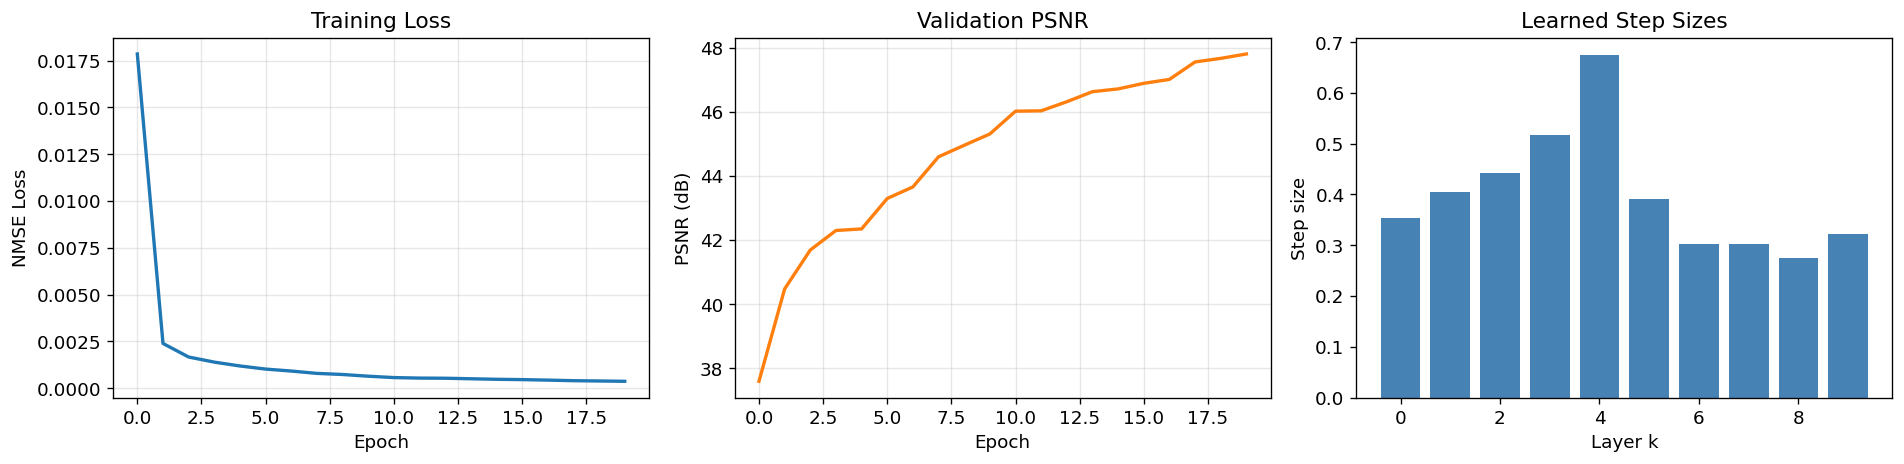

In [51]:
# training curves + learned step sizes
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(train_losses, lw=2); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("NMSE Loss")
axes[0].set_title("Training Loss"); axes[0].grid(True, alpha=0.3)

axes[1].plot(val_psnrs, lw=2, color="tab:orange"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("PSNR (dB)"); axes[1].set_title("Validation PSNR"); axes[1].grid(True, alpha=0.3)

steps = torch.exp(model.log_step).detach().cpu().numpy()
axes[2].bar(range(len(steps)), steps, color="steelblue")
axes[2].set_xlabel("Layer k"); axes[2].set_ylabel("Step size"); axes[2].set_title("Learned Step Sizes")
plt.tight_layout(); plt.show()

## Fair Comparison: Unrolled vs Tuned Classical Baselines

All methods: **K=10 iterations/layers**, same mask and image.
Classical baselines tuned via grid search over `(step, λ)`.

In [52]:
R_test = 4
rng_test = np.random.default_rng(77)
mask_test_np = random_cartesian_mask(N, accel=R_test, center_frac=center_frac, rng=rng_test)
y_test_np = A_np(image_np, mask_test_np)
zf_test = np.real(AT_np(y_test_np, mask_test_np))

K_test = 10
best_ista = {"psnr": -1e9}
best_fista = {"psnr": -1e9}

for step in [0.1, 0.2, 0.3, 0.4]:
    for lam in [0.001, 0.002, 0.005, 0.01, 0.02]:
        xi = ista_np(y_test_np, mask_test_np, K=K_test, step=step, lam=lam)
        pi = compute_psnr_np(xi, image_np)
        if pi > best_ista["psnr"]:
            best_ista = {"psnr": pi, "step": step, "lam": lam, "recon": xi}

        xf = fista_np(y_test_np, mask_test_np, K=K_test, step=step, lam=lam)
        pf = compute_psnr_np(xf, image_np)
        if pf > best_fista["psnr"]:
            best_fista = {"psnr": pf, "step": step, "lam": lam, "recon": xf}

print(f"Best ISTA  (K={K_test}): PSNR={best_ista['psnr']:.2f}, step={best_ista['step']}, lam={best_ista['lam']}")
print(f"Best FISTA (K={K_test}): PSNR={best_fista['psnr']:.2f}, step={best_fista['step']}, lam={best_fista['lam']}")

Best ISTA  (K=10): PSNR=20.28, step=0.4, lam=0.02
Best FISTA (K=10): PSNR=20.56, step=0.4, lam=0.02


In [53]:
mask_test_t = torch.from_numpy(mask_test_np).to(device).to(torch.complex64).unsqueeze(0)
x_gt_t = torch.from_numpy(image_np).to(device).float().unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    y_t = A_torch(x_gt_t, mask_test_t)
    unrolled_np = model(y_t, mask_test_t).squeeze().cpu().numpy()

methods = {
    "Zero-fill": zf_test,
    f"ISTA (db4, K={K_test})": best_ista["recon"],
    f"FISTA (db4, K={K_test})": best_fista["recon"],
    f"Unrolled (K={K_test})": unrolled_np,
}

print(f"\n{'Method':<25s} {'PSNR':>8s} {'SSIM':>8s} {'NMSE':>10s}")
print("-" * 55)
for name, recon in methods.items():
    p = compute_psnr_np(recon, image_np)
    s = compute_ssim_np(recon, image_np)
    n = float(np.sum((recon - image_np)**2) / (np.sum(image_np**2) + 1e-12))
    print(f"{name:<25s} {p:8.2f} {s:8.4f} {n:10.6f}")


Method                        PSNR     SSIM       NMSE
-------------------------------------------------------
Zero-fill                    19.41   0.3811   0.194956
ISTA (db4, K=10)             20.28   0.3366   0.159441
FISTA (db4, K=10)            20.56   0.3489   0.149454
Unrolled (K=10)              39.84   0.9904   0.001766


## Publication Figure

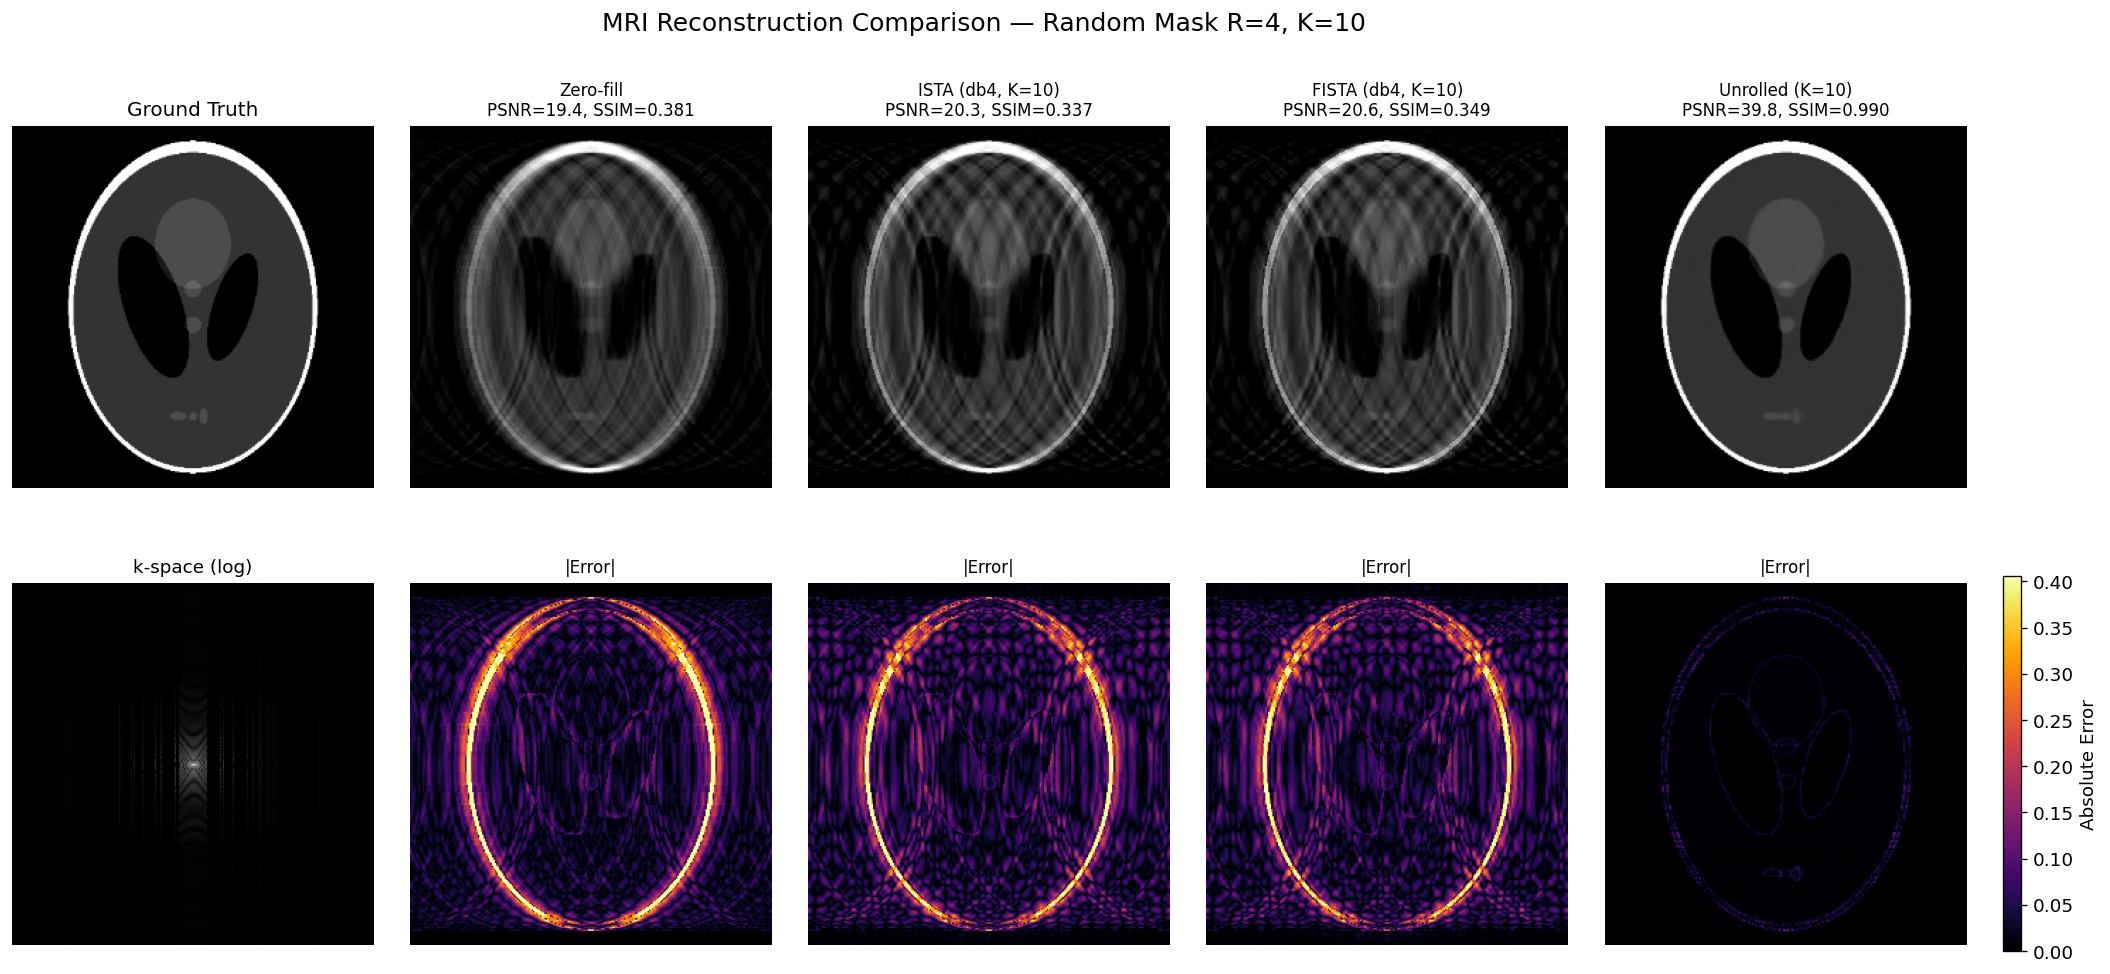

In [54]:
def paper_figure_nb3(truth, recons_dict, y_kspace, title=""):
    """Publication figure with GridSpec + dedicated colorbar column."""
    names = list(recons_dict.keys())
    recons = list(recons_dict.values())
    n = len(names)
    vmin, vmax = float(truth.min()), float(truth.max())

    errors = [np.abs(r - truth) for r in recons]
    emax = float(np.quantile(np.stack(errors).ravel(), 0.99))


    fig = plt.figure(figsize=(4.2 * (n + 1) + 0.6, 9))
    gs = gridspec.GridSpec(2, n + 2,
                           width_ratios=[1] * (n + 1) + [0.05],
                           wspace=0.12, hspace=0.22)



    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(truth, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title("Ground Truth", fontsize=12); ax.axis("off")

    ax = fig.add_subplot(gs[1, 0])
    kvis = np.log1p(np.abs(np.fft.fftshift(y_kspace)))
    ax.imshow(kvis, cmap="gray"); ax.set_title("k-space (log)", fontsize=11); ax.axis("off")


    for i, (name, recon, err) in enumerate(zip(names, recons, errors)):
        p = compute_psnr_np(recon, truth)
        s = compute_ssim_np(recon, truth)

        ax = fig.add_subplot(gs[0, i + 1])
        ax.imshow(recon, cmap="gray", vmin=vmin, vmax=vmax)
        ax.set_title(f"{name}\nPSNR={p:.1f}, SSIM={s:.3f}", fontsize=10)
        ax.axis("off")

        ax = fig.add_subplot(gs[1, i + 1])
        im = ax.imshow(err, cmap="inferno", vmin=0, vmax=emax)
        ax.set_title("|Error|", fontsize=10); ax.axis("off")


    cax = fig.add_subplot(gs[1, n + 1])
    fig.colorbar(im, cax=cax, label="Absolute Error")

    fig.suptitle(title, fontsize=15, y=0.98)
    plt.show()


paper_figure_nb3(
    image_np, methods, y_test_np,
    title=f"MRI Reconstruction Comparison — Random Mask R={R_test}, K={K_test}"
)

## Quality vs Number of Iterations/Layers

**Caveat**: The unrolled network was trained end-to-end with K=10. Evaluating
at K < 10 uses layers optimized as intermediate steps, not final outputs.

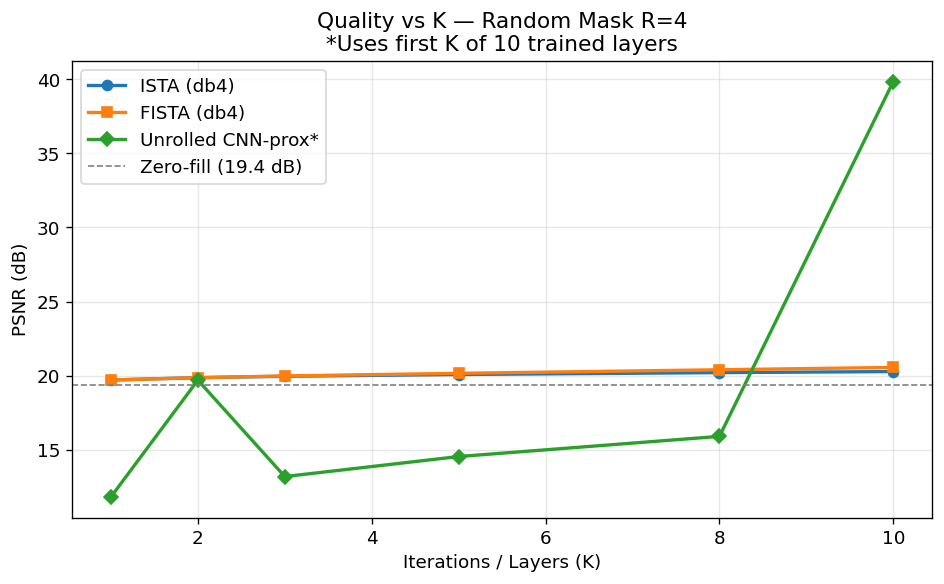

In [55]:
Ks = [1, 2, 3, 5, 8, 10]
ista_psnrs, fista_psnrs, unrolled_psnrs = [], [], []

for K in Ks:
    xi = ista_np(y_test_np, mask_test_np, K=K, step=best_ista["step"], lam=best_ista["lam"])
    xf = fista_np(y_test_np, mask_test_np, K=K, step=best_fista["step"], lam=best_fista["lam"])
    ista_psnrs.append(compute_psnr_np(xi, image_np))
    fista_psnrs.append(compute_psnr_np(xf, image_np))

    model_trunc = UnrolledISTA(K=K, init_step=0.2, channels=16, share_prox=False).to(device)
    with torch.no_grad():
        model_trunc.log_step.data[:] = model.log_step.data[:K]
        for kk in range(K):
            model_trunc.prox_layers[kk].load_state_dict(model.prox_layers[kk].state_dict())
    model_trunc.eval()
    with torch.no_grad():
        xu = model_trunc(y_t, mask_test_t).squeeze().cpu().numpy()
    unrolled_psnrs.append(compute_psnr_np(xu, image_np))

zf_psnr = compute_psnr_np(zf_test, image_np)

plt.figure(figsize=(8, 5))
plt.plot(Ks, ista_psnrs, "o-", lw=2, label="ISTA (db4)")
plt.plot(Ks, fista_psnrs, "s-", lw=2, label="FISTA (db4)")
plt.plot(Ks, unrolled_psnrs, "D-", lw=2, label="Unrolled CNN-prox*")
plt.axhline(zf_psnr, color="gray", ls="--", lw=1, label=f"Zero-fill ({zf_psnr:.1f} dB)")
plt.xlabel("Iterations / Layers (K)"); plt.ylabel("PSNR (dB)")
plt.title(f"Quality vs K — Random Mask R={R_test}\n*Uses first K of 10 trained layers")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Summary

The unrolled network with learned CNN proximal operators outperforms classical
wavelet-based ISTA/FISTA at the same iteration count:

- **Data consistency is crucial** — all methods share the physics-based gradient step
- **Learned prox > wavelet prox** — the CNN learns a richer image prior
- **FISTA momentum helps** — consistent improvement over ISTA at same K
- **Caveat**: Results are on phantom data only; generalization requires diverse training data